In [12]:
# ── Step 1: Upload the CSV ────────────────────────────────
from google.colab import files
print("Upload customer_support_text_classification.csv")
uploaded = files.upload()

# ── Step 2: Install libraries ─────────────────────────────
import subprocess
subprocess.run(["pip", "install", "--quiet",
                 "tensorflow", "scikit-learn", "pandas",
                 "numpy", "matplotlib", "seaborn", "nltk"])

# ── Step 3: Download NLTK data ────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Step 4: Create results folder ────────────────────────
import os
os.makedirs('results', exist_ok=True)
print(" Setup complete — run cells in order")

Upload customer_support_text_classification.csv


Saving customer_support_text_classification.csv to customer_support_text_classification.csv
 Setup complete — run cells in order


Shape   : 1500 rows × 6 columns
Columns : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

── Sample records ──
                                                                                            customer_message sentiment_label
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.         neutral
                                                               I need information about the payment process.         neutral
                                The refund process was fast and convenient. I appreciate the quick response.        positive
                   My refund is still pending and this experience is frustrating. My ticket number is 33927.        negative
                                                            Please tell me how to update my account details.         neutral

── Class distribution ──
sentiment_label
neutral     524
negative    497
positive    479
Nam

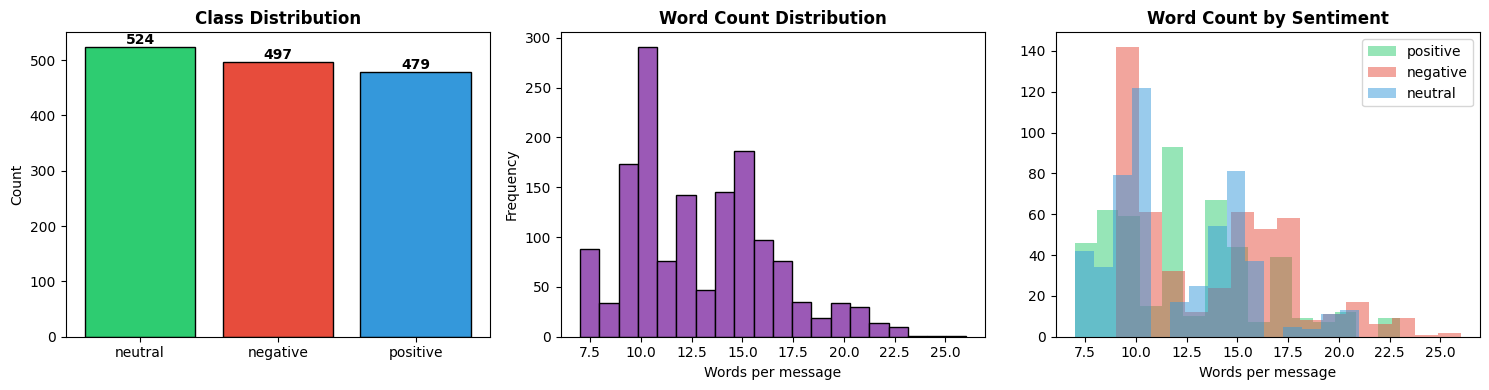

Task 1 complete


In [14]:
## Task 1 — Dataset Understanding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load dataset ──────────────────────────────────────────
df = pd.read_csv('customer_support_text_classification.csv')
print(f"Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}")

# ── Task setup: text → sentiment ─────────────────────────
# Input  : customer_message  (free text)
# Target : sentiment_label   (positive / negative / neutral)
TEXT_COL   = 'customer_message'
TARGET_COL = 'sentiment_label'

# ── Sample records ────────────────────────────────────────
print("\n── Sample records ──")
print(df[[TEXT_COL, TARGET_COL]].head(5).to_string(index=False))

# ── Class distribution ────────────────────────────────────
print("\n── Class distribution ──")
print(df[TARGET_COL].value_counts())

# ── Text length stats ─────────────────────────────────────
df['char_len'] = df[TEXT_COL].apply(len)
df['word_len'] = df[TEXT_COL].apply(lambda x: len(x.split()))
print(f"\nAvg chars per message : {df['char_len'].mean():.1f}")
print(f"Avg words per message : {df['word_len'].mean():.1f}")
print(f"Max words             : {df['word_len'].max()}")

# ── Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
counts = df[TARGET_COL].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

# Word count distribution
axes[1].hist(df['word_len'], bins=20, color='#9b59b6', edgecolor='black')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Words per message')
axes[1].set_ylabel('Frequency')

# Word count by class
for label, color in zip(['positive','negative','neutral'], colors):
    subset = df[df[TARGET_COL]==label]['word_len']
    axes[2].hist(subset, bins=15, alpha=0.5, label=label, color=color)
axes[2].set_title('Word Count by Sentiment', fontweight='bold')
axes[2].set_xlabel('Words per message')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/task1_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task 1 complete")

In [15]:
## Task 2 — Text Preprocessing
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove ticket numbers (e.g. "My ticket number is 12345")
    text = re.sub(r'my ticket number is \d+', '', text)
    # 3. Remove special characters and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Remove stopwords (keep sentiment words like "not", "very")
    keep = {'not', 'no', 'very', 'too', 'but'}
    tokens = [t for t in tokens
              if t not in STOPWORDS or t in keep]
    return ' '.join(tokens)

# ── Apply cleaning ────────────────────────────────────────
df['clean_text'] = df[TEXT_COL].apply(clean_text)

# ── Show before / after ───────────────────────────────────
print("── Before / After Cleaning ──")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL : {df[TEXT_COL].iloc[i]}")
    print(f"    CLEANED  : {df['clean_text'].iloc[i]}")

# ── Encode labels ─────────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df[TARGET_COL])
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
# → {'negative': 0, 'neutral': 1, 'positive': 2}

# ── Train / test split (used by all tasks below) ──────────
from sklearn.model_selection import train_test_split
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)
print(f"\nTrain: {len(X_train_txt)} | Test: {len(X_test_txt)}")
print("Task 2 complete")

── Before / After Cleaning ──

[1] ORIGINAL : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
    CLEANED  : need information payment process please respond soon possible

[2] ORIGINAL : I need information about the payment process.
    CLEANED  : need information payment process

[3] ORIGINAL : The refund process was fast and convenient. I appreciate the quick response.
    CLEANED  : refund process fast convenient appreciate quick response

Label encoding: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Train: 1200 | Test: 300
Task 2 complete


BoW matrix shape  : (1200, 148)
Sample vocab (10) : ['account', 'activate', 'ago', 'analytics', 'app', 'appreciate', 'arrived', 'assigned', 'available', 'bad']

TF-IDF matrix shape: (1200, 393)

Sequence shape (train): (1200, 30)
Sequence shape (test) : (300, 30)

Sample raw   : confirm whether ticket assigned please respond soon possible
Sample padded: [65 66 67 68  2  3  4  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]


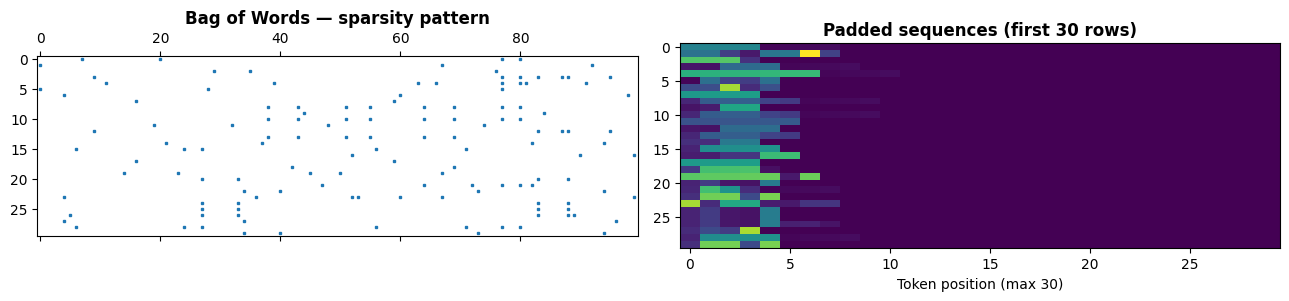

Task 3 complete


In [16]:
## Task 3 — Text Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import tensorflow as tf

# ── Why vectorization? ────────────────────────────────────
# ML/DL models only understand numbers.
# "frustrating" has no mathematical meaning until mapped
# to a vector. Vectorization is the bridge between raw
# text and numerical computation.

# ── Method 1: Bag of Words (CountVectorizer) ──────────────
bow = CountVectorizer(max_features=3000)
X_train_bow = bow.fit_transform(X_train_txt)
X_test_bow  = bow.transform(X_test_txt)
print(f"BoW matrix shape  : {X_train_bow.shape}")
print(f"Sample vocab (10) : {bow.get_feature_names_out()[:10].tolist()}")

# ── Method 2: TF-IDF ──────────────────────────────────────
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf  = tfidf.transform(X_test_txt)
print(f"\nTF-IDF matrix shape: {X_train_tfidf.shape}")

# ── Method 3: Tokenizer sequences (for LSTM in Task 5) ────
VOCAB_SIZE  = 5000
MAX_LEN     = 30    # 95th percentile of word counts

tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_txt)

X_train_seq = tokenizer.texts_to_sequences(X_train_txt)
X_test_seq  = tokenizer.texts_to_sequences(X_test_txt)

X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = tf.keras.preprocessing.sequence.pad_sequences(
    X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nSequence shape (train): {X_train_pad.shape}")
print(f"Sequence shape (test) : {X_test_pad.shape}")
print(f"\nSample raw   : {X_train_txt.iloc[0]}")
print(f"Sample padded: {X_train_pad[0]}")

# ── Compare methods visually ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].spy(X_train_bow[:30, :100], markersize=2)
axes[0].set_title('Bag of Words — sparsity pattern', fontweight='bold')
axes[1].imshow(X_train_pad[:30], aspect='auto', cmap='viridis')
axes[1].set_title('Padded sequences (first 30 rows)', fontweight='bold')
axes[1].set_xlabel('Token position (max 30)')
plt.tight_layout()
plt.savefig('results/vectorization_view.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task 3 complete")

Logistic Regression Accuracy : 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Naive Bayes Accuracy         : 1.0000


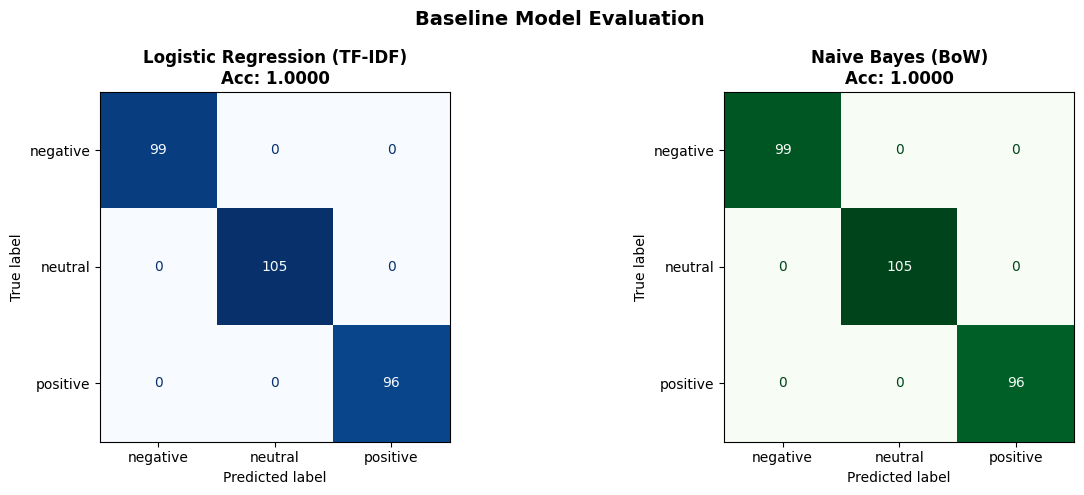

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task 4 complete — 2 files downloaded


In [17]:
## Task 4 — Baseline Model (Logistic Regression + TF-IDF)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                               ConfusionMatrixDisplay, accuracy_score)
from google.colab import files

# ── Model A: Logistic Regression + TF-IDF ─────────────────
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
acc_lr    = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy : {acc_lr:.4f}")
print(classification_report(y_test, y_pred_lr,
      target_names=le.classes_))

# ── Model B: Naive Bayes + Bag of Words ───────────────────
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
y_pred_nb = nb.predict(X_test_bow)
acc_nb    = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy         : {acc_nb:.4f}")

# ── Plot: both confusion matrices side by side ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=le.classes_
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Logistic Regression (TF-IDF)\nAcc: {acc_lr:.4f}',
                  fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_nb),
    display_labels=le.classes_
).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Naive Bayes (BoW)\nAcc: {acc_nb:.4f}',
                  fontweight='bold')

plt.suptitle('Baseline Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('results/model_evaluation.png')

# ── Save sample predictions ───────────────────────────────
X_test_list = X_test_txt.tolist()
true_labels = [le.classes_[i] for i in y_test]
pred_labels = [le.classes_[i] for i in y_pred_lr]

with open('results/sample_predictions.txt', 'w') as f:
    f.write("Sample Predictions — Logistic Regression (TF-IDF)\n")
    f.write("="*60 + "\n\n")
    for i in range(20):
        status = "✓" if true_labels[i] == pred_labels[i] else "✗"
        f.write(f"[{status}] Text  : {X_test_list[i]}\n")
        f.write(f"     True  : {true_labels[i]}\n")
        f.write(f"     Pred  : {pred_labels[i]}\n\n")
    f.write(f"\nOverall Accuracy: {acc_lr:.4f}\n")

files.download('results/sample_predictions.txt')
print("Task 4 complete — 2 files downloaded")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sentiment_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.5927 - loss: 1.0319 - val_accuracy: 0.9958 - val_loss: 0.8031
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9531 - loss: 0.3457 - val_accuracy: 1.0000 - val_loss: 0.0358
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9990 - loss: 0.0166 - val_accuracy: 1.0000 - val_loss: 4.6983e-04
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9990 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 8.0000e-04
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 1.1862e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 6.5685e-04 - val_accuracy: 1.0000 - val_loss: 4.7232e-05
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 8.5416e-05
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 1.0000 - loss: 5.4640e

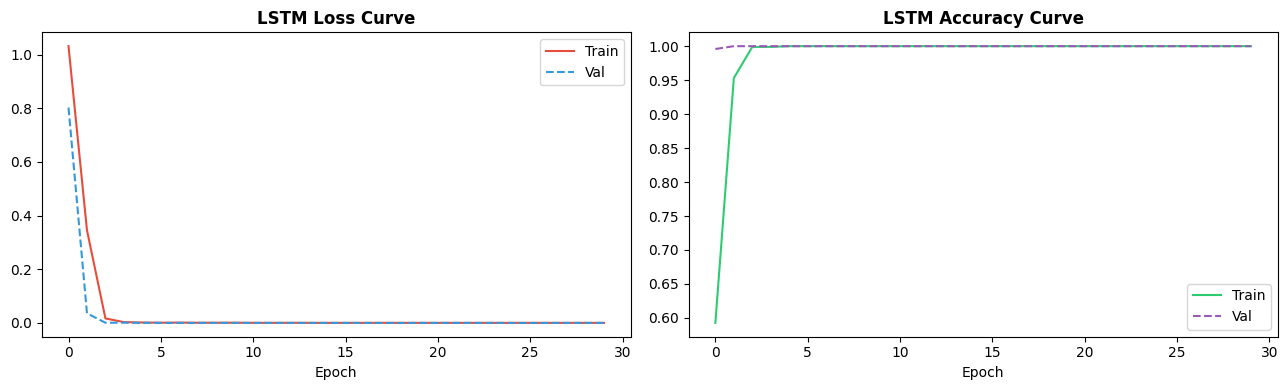


── Model Comparison ──
Logistic Regression (TF-IDF) : 1.0000
Naive Bayes (BoW)            : 1.0000
Bidirectional LSTM           : 1.0000
Task 5 complete


In [19]:
## Task 5 — LSTM Sequence Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense,
                                        Dropout, Bidirectional,
                                        GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

EMBED_DIM   = 64
LSTM_UNITS  = 64
NUM_CLASSES = 3

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
               input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax'),
], name='sentiment_lstm')

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ── Train ─────────────────────────────────────────────────
es = EarlyStopping(patience=5, restore_best_weights=True,
                   monitor='val_loss')
history = model.fit(
    X_train_pad, y_train,
    epochs=30, batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

# ── Evaluate ──────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nLSTM Test Accuracy : {test_acc:.4f}")
print(f"LSTM Test Loss     : {test_loss:.4f}")

y_pred_lstm = np.argmax(
    model.predict(X_test_pad, verbose=0), axis=1)
print(classification_report(y_test, y_pred_lstm,
      target_names=le.classes_))

# ── Plot curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train', color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val',   color='#3498db', linestyle='--')
axes[0].set_title('LSTM Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='#9b59b6', linestyle='--')
axes[1].set_title('LSTM Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('results/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Model comparison summary ──────────────────────────────
print("\n── Model Comparison ──")
print(f"Logistic Regression (TF-IDF) : {acc_lr:.4f}")
print(f"Naive Bayes (BoW)            : {acc_nb:.4f}")
print(f"Bidirectional LSTM           : {test_acc:.4f}")


print("Task 5 complete")

## Task 6 — Attention and Transformer Reflection

### Why RNNs struggle with long-term dependencies
RNNs process tokens one at a time, passing a fixed-size
hidden state forward. By the time the model reaches token
50, information from token 1 has been repeatedly
compressed and overwritten. This is the vanishing gradient
problem — gradients shrink exponentially as they travel
backward through time, so early tokens barely influence
the weight updates. In practice, RNNs forget context
beyond ~10-20 tokens.

### How LSTMs help with memory
LSTMs add three gating mechanisms to the basic RNN:
  • Forget gate  — decides what to erase from cell state
  • Input gate   — decides what new info to write
  • Output gate  — decides what to expose as hidden state

The cell state acts as a conveyor belt that can carry
information across hundreds of steps with minimal
modification. This lets LSTMs remember that "not" at
position 2 negates "satisfied" at position 15, which a
plain RNN would lose.

### What attention solves in sequence-to-sequence tasks
Even LSTMs must compress the entire input into one vector
before decoding — a bottleneck for long inputs (e.g.
machine translation of a 100-word sentence).

Attention lets the decoder look back at ALL encoder
hidden states at each decoding step, and compute a
weighted sum — putting more focus on the relevant tokens.
This means:
  • No fixed-size bottleneck
  • The model "re-reads" the input selectively
  • Long-range dependencies become trivial
  • Gradient paths shorten drastically (any token
    can attend to any other in one step)

### Why transformers dominate modern NLP and GenAI
Transformers (Vaswani et al., 2017) replaced recurrence
entirely with self-attention — every token attends to
every other token in parallel:

  Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V

Key advantages:
  • Parallelism: no sequential dependency → GPUs fully
    utilised → 10-100× faster training than LSTMs
  • Scalability: performance keeps improving with more
    data and parameters (GPT-4 ~1.8T params)
  • Positional encoding: order is injected via sine/
    cosine embeddings, not recurrence
  • Bidirectional context: every token sees all others
    simultaneously (BERT) or left-context autoregressively
    (GPT)

Modern LLMs (GPT-4, Gemini, Claude) are all transformer-
based. Their ability to generate coherent long-form text,
answer questions, and write code comes directly from
self-attention's ability to model arbitrary long-range
dependencies without the bottleneck of sequential state.